In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def perform_pca(df, n_components=None, features=None):
    """
    Perform PCA analysis on a dataset
    
    Parameters:
    df: DataFrame containing the features
    n_components: Number of components to keep (default=None, keeps all)
    features: List of feature columns to use (default=None, uses all numeric columns)
    
    Returns:
    dict containing PCA results
    """
    # Select features
    if features is None:
        features = df.select_dtypes(include=['float64', 'int64']).columns
    
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create DataFrame with principal components
    pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    pc_df = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)
    
    # Calculate explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # Get component loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=pc_cols,
        index=features
    )
    
    return {
        'pca': pca,
        'transformed_data': pc_df,
        'explained_variance_ratio': explained_variance_ratio,
        'cumulative_variance_ratio': cumulative_variance_ratio,
        'loadings': loadings,
        'scaler': scaler
    }

def plot_explained_variance(explained_variance_ratio, cumulative_variance_ratio):
    """Plot explained variance ratio"""
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(explained_variance_ratio) + 1), 
            explained_variance_ratio, 
            alpha=0.5, 
            label='Individual explained variance')
    plt.step(range(1, len(cumulative_variance_ratio) + 1),
             cumulative_variance_ratio,
             where='mid',
             label='Cumulative explained variance')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Scree Plot')
    plt.legend()
    plt.show()

def plot_loading_heatmap(loadings):
    """Plot component loadings heatmap"""
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
    plt.title('PCA Loading Heatmap')
    plt.show()

def biplot(transformed_data, loadings, features, pc1=1, pc2=2):
    """Create a biplot of two principal components"""
    plt.figure(figsize=(10, 8))
    
    # Plot transformed data points
    plt.scatter(transformed_data[f'PC{pc1}'], 
               transformed_data[f'PC{pc2}'],
               alpha=0.5)
    
    # Plot feature vectors
    for i, feature in enumerate(features):
        plt.arrow(0, 0,
                 loadings.iloc[i, pc1-1] * 3,
                 loadings.iloc[i, pc2-1] * 3,
                 color='r',
                 alpha=0.5)
        plt.text(loadings.iloc[i, pc1-1] * 3.2,
                loadings.iloc[i, pc2-1] * 3.2,
                feature)
    
    plt.xlabel(f'PC{pc1}')
    plt.ylabel(f'PC{pc2}')
    plt.title(f'Biplot: PC{pc1} vs PC{pc2}')
    plt.grid()
    plt.show()

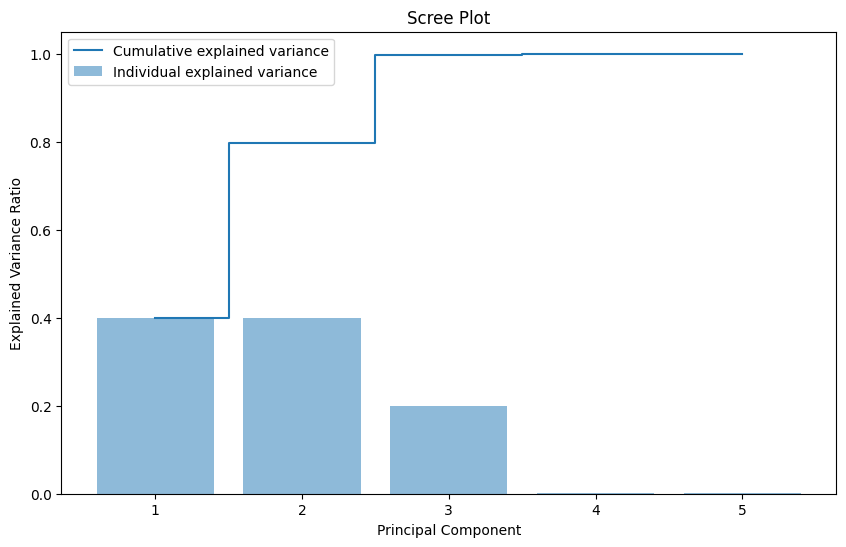

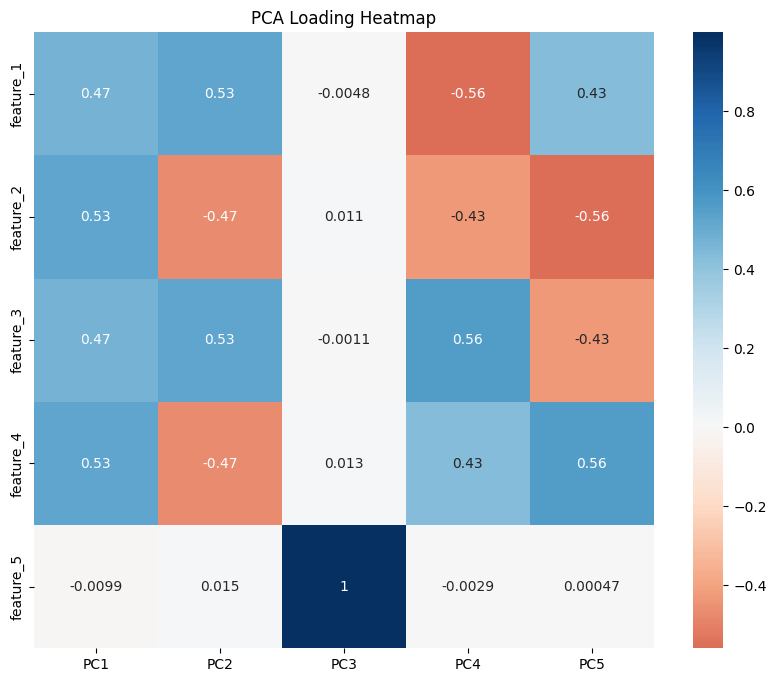

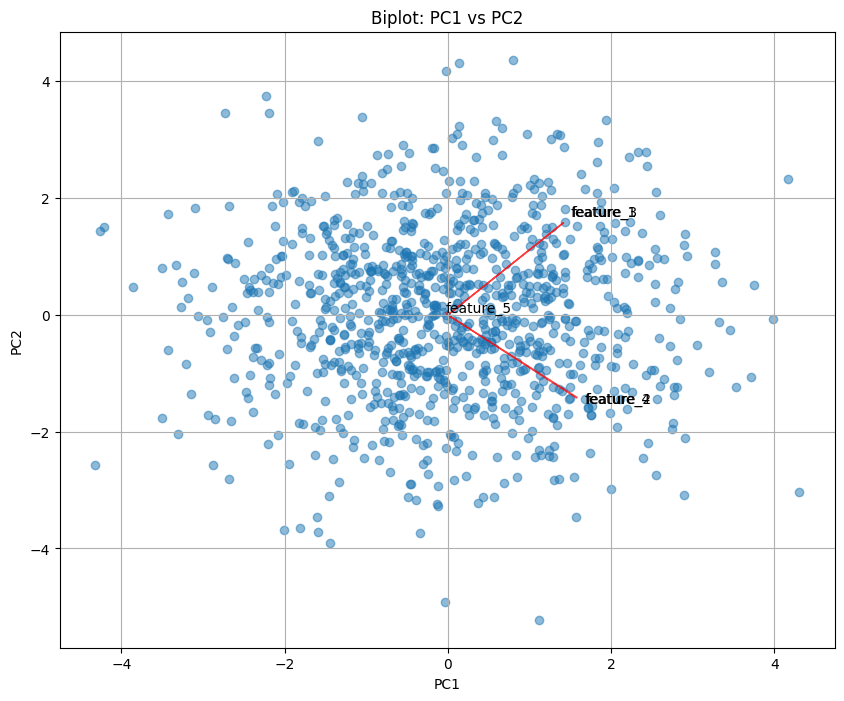


Explained variance ratio by component:
PC1: 0.3993
PC2: 0.3987
PC3: 0.1999
PC4: 0.0010
PC5: 0.0010

Cumulative explained variance ratio:
PC1 to PC1: 0.3993
PC1 to PC2: 0.7980
PC1 to PC3: 0.9980
PC1 to PC4: 0.9990
PC1 to PC5: 1.0000


In [10]:
# Create sample dataset
np.random.seed(42)
n_samples = 1000
n_features = 5

# Create correlated features
X = np.random.randn(n_samples, 2)
X = np.hstack([X, X[:, 0:1] + np.random.randn(n_samples, 1) * 0.1,
               X[:, 1:2] + np.random.randn(n_samples, 1) * 0.1,
               np.random.randn(n_samples, 1)])

df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])

# Perform PCA
results = perform_pca(df)

# Plot results
plot_explained_variance(
    results['explained_variance_ratio'],
    results['cumulative_variance_ratio']
)

# Plot loadings heatmap
plot_loading_heatmap(results['loadings'])

# Create biplot
biplot(results['transformed_data'],
       results['loadings'],
       df.columns)

# Print variance explained by each component
print("\nExplained variance ratio by component:")
for i, ratio in enumerate(results['explained_variance_ratio'], 1):
    print(f"PC{i}: {ratio:.4f}")

print("\nCumulative explained variance ratio:")
for i, ratio in enumerate(results['cumulative_variance_ratio'], 1):
    print(f"PC1 to PC{i}: {ratio:.4f}")

In [11]:
df 

,feature_1,feature_2,feature_3,feature_4,feature_5
0,0.496714,-0.138264,0.429196,-0.329045,-0.863494
1,0.647689,1.523030,0.633237,1.436991,-0.031203
2,-0.234153,-0.234137,-0.313395,-0.275498,0.018017
3,1.579213,0.767435,1.548417,0.956203,0.472630
4,-0.469474,0.542560,-0.658836,0.598215,-1.366858
...,...,...,...,...,...
995,0.800410,0.754291,0.808158,0.757137,-0.048965
996,1.188913,0.708304,1.214689,0.500523,0.711411
997,0.351448,1.070150,0.227272,1.038120,3.112910
998,-0.026521,-0.881875,0.006896,-0.717537,0.808036


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def standardize_data(X):
    """
    Standardize the data to have mean=0 and variance=1
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

# Example usage
data = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5],
    'feature2': [2, 4, 5, 4, 5],
    'feature3': [3, 3, 3, 3, 3]
})

X_scaled, scaler = standardize_data(data)

In [16]:
display(data)
display(X_scaled)

,feature1,feature2,feature3
0,1,2,3
1,2,4,3
2,3,5,3
3,4,4,3
4,5,5,3


array([[-1.41421356, -1.82574186,  0.        ],
       [-0.70710678,  0.        ,  0.        ],
       [ 0.        ,  0.91287093,  0.        ],
       [ 0.70710678,  0.        ,  0.        ],
       [ 1.41421356,  0.91287093,  0.        ]])

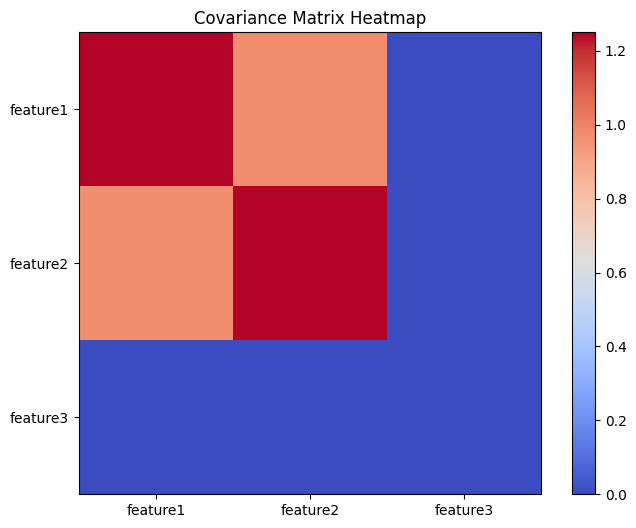

In [17]:
def compute_covariance_matrix(X_scaled):
    """
    Compute the covariance matrix
    """
    cov_matrix = np.cov(X_scaled.T)
    return cov_matrix

# Example usage
covariance_matrix = compute_covariance_matrix(X_scaled)

# Visualize covariance matrix
plt.figure(figsize=(8, 6))
plt.imshow(covariance_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(data.columns)), data.columns)
plt.yticks(range(len(data.columns)), data.columns)
plt.title('Covariance Matrix Heatmap')
plt.show()

In [13]:
def find_optimal_components(explained_variance_ratio, threshold=0.95):
    """
    Find number of components needed to explain desired variance
    
    Parameters:
    explained_variance_ratio: Array of explained variance ratios
    threshold: Desired cumulative explained variance (default=0.95)
    
    Returns:
    int: Number of components needed
    """
    cumulative = np.cumsum(explained_variance_ratio)
    n_components = np.argmax(cumulative >= threshold) + 1
    return n_components

# Example usage
n_components = find_optimal_components(results['explained_variance_ratio'])
print(f"\nNumber of components needed to explain {95}% of variance: {n_components}")


Number of components needed to explain 95% of variance: 3
